# 🍽️ Restaurant Tipping Prediction: ML for Hospitality & Labour Economics

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **Fair Work Commission** — Minimum wage, hospitality award rates
- **ATO** — Tip income reporting, cash economy compliance
- **ABS** — Household expenditure survey, hospitality sector analytics
- **Safe Work Australia** — Hospitality workplace safety
- **Tourism Australia** — Food tourism, hospitality service quality

Dataset: Tips — seaborn built-in, 244 rows, 7 columns, regression. Guaranteed clean.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
# Use seaborn built-in dataset — GUARANTEED to work
df = sns.load_dataset('tips')
print(f"Loaded seaborn tips dataset: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:15s} | {str(df[col].dtype):10s} | uniq={df[col].nunique():5d}")
df.head()

Loaded seaborn tips dataset: 244 x 7
   0. total_bill      | float64    | uniq=  229
   1. tip             | float64    | uniq=  123
   2. sex             | category   | uniq=    2
   3. smoker          | category   | uniq=    2
   4. day             | category   | uniq=    4
   5. time            | category   | uniq=    2
   6. size            | int64      | uniq=    6


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Target

Target: 'tip'
count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64


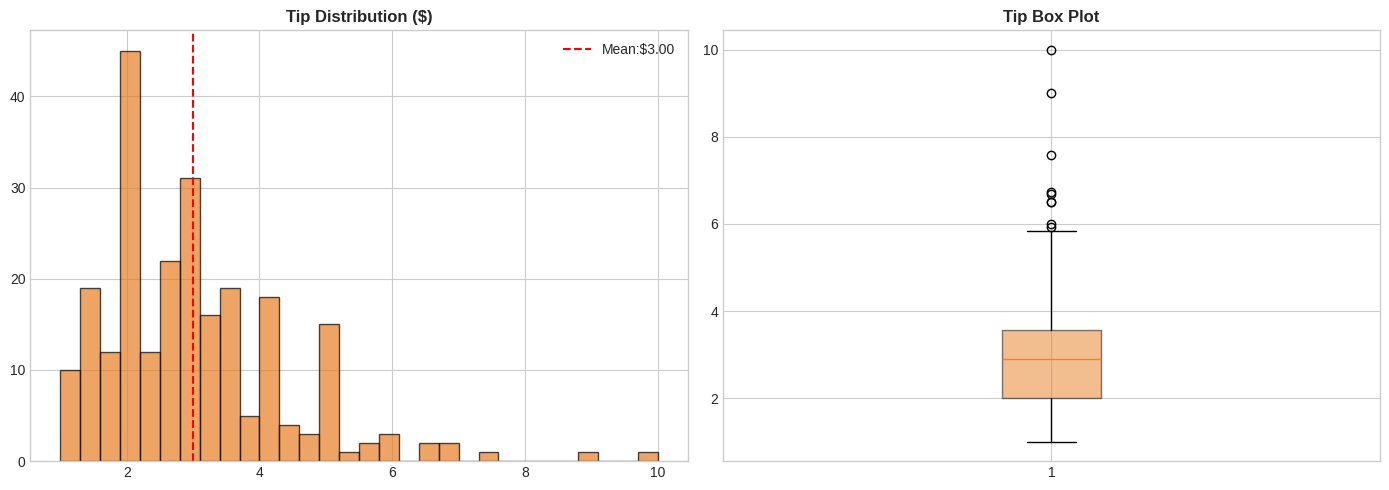

AU: Tipping not customary but growing. Fair Work minimum wage $24.10/hr (2024).


In [2]:
tc='tip'
print(f"Target: '{tc}'");print(df[tc].describe())
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df[tc],bins=30,color='#e67e22',edgecolor='black',alpha=0.7)
axes[0].set_title('Tip Distribution ($)',fontweight='bold')
axes[0].axvline(df[tc].mean(),color='red',ls='--',label=f'Mean:${df[tc].mean():.2f}')
axes[0].legend()
axes[1].boxplot(df[tc],patch_artist=True,boxprops=dict(facecolor='#e67e22',alpha=0.5))
axes[1].set_title('Tip Box Plot',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: Tipping not customary but growing. Fair Work minimum wage $24.10/hr (2024).")

## 3. EDA

Numeric: ['total_bill', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


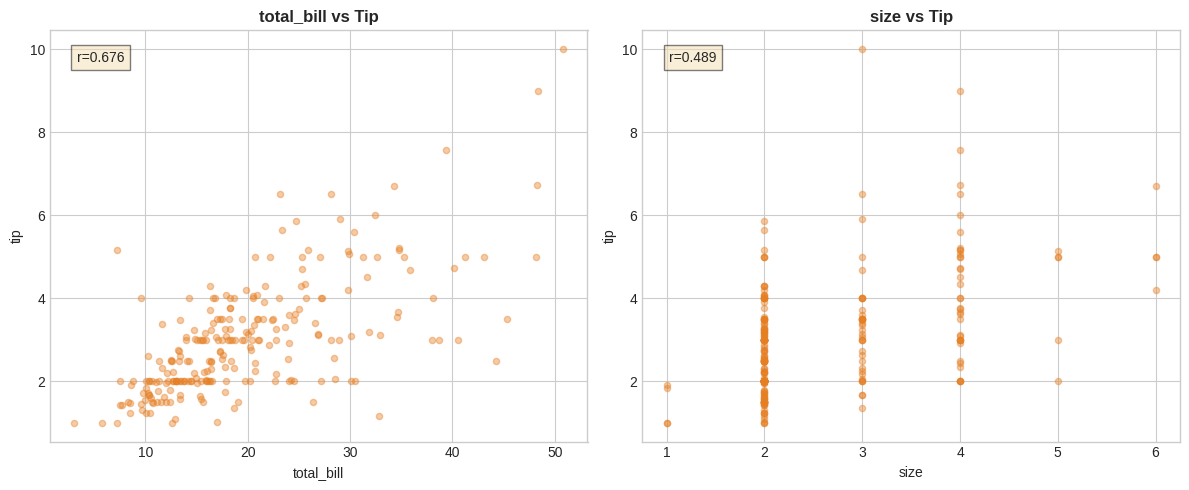

In [3]:
nums=[c2 for c2 in df.select_dtypes(include=[np.number]).columns if c2!=tc]
cats=[c2 for c2 in df.select_dtypes(include=['category','object']).columns]
print(f"Numeric: {nums}");print(f"Categorical: {cats}")
fig,axes=plt.subplots(1,len(nums),figsize=(6*len(nums),5))
if not isinstance(axes,np.ndarray): axes=[axes]
for i,col in enumerate(nums):
    axes[i].scatter(df[col],df[tc],alpha=0.4,s=20,color='#e67e22')
    axes[i].set_xlabel(col);axes[i].set_ylabel('tip')
    axes[i].set_title(f'{col} vs Tip',fontweight='bold')
    r=df[[col,tc]].corr().iloc[0,1]
    axes[i].text(0.05,0.95,f'r={r:.3f}',transform=axes[i].transAxes,va='top',bbox=dict(facecolor='wheat',alpha=0.5))
plt.tight_layout();plt.savefig('scatter.png',dpi=150);plt.show()

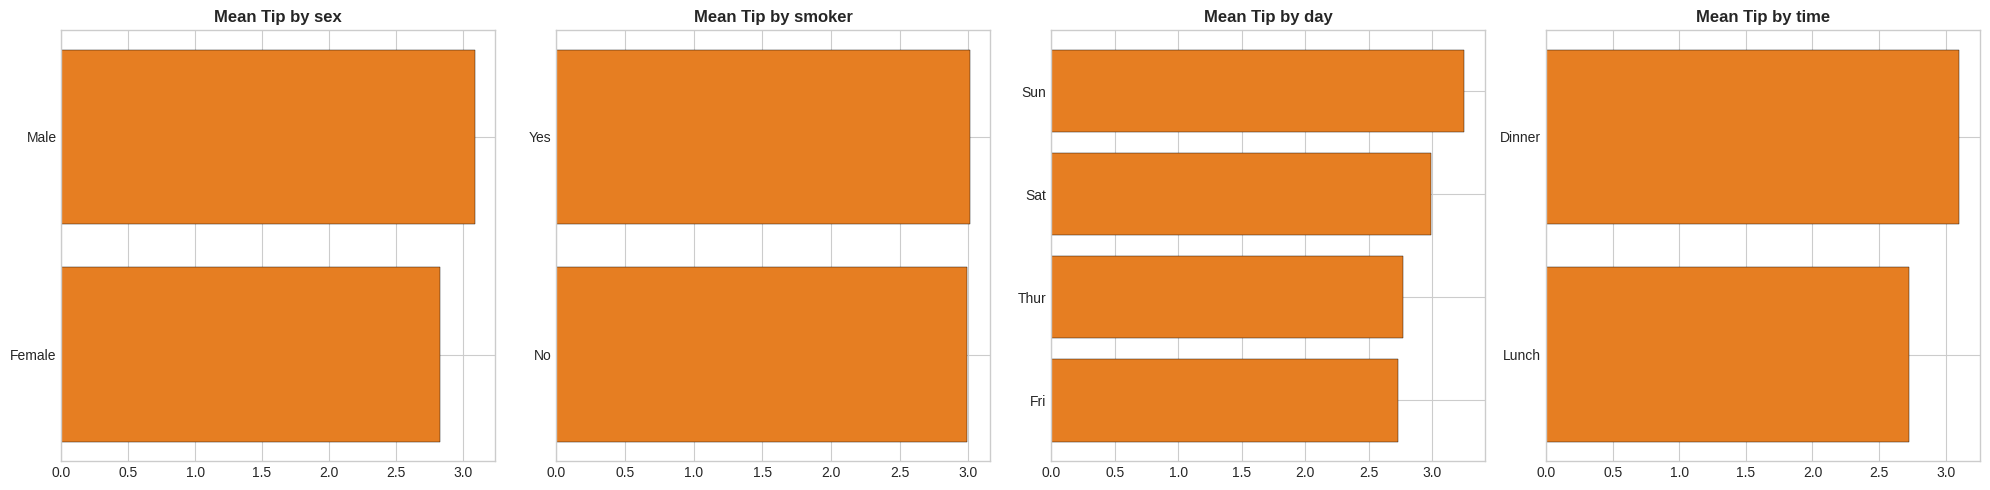

In [4]:
if len(cats)>0:
    fig,axes=plt.subplots(1,min(len(cats),4),figsize=(5*min(len(cats),4),5))
    if not isinstance(axes,np.ndarray): axes=[axes]
    for i,col in enumerate(cats[:4]):
        means=df.groupby(col)[tc].mean().sort_values()
        axes[i].barh(means.index.astype(str),means.values,color='#e67e22',edgecolor='black',linewidth=0.3)
        axes[i].set_title(f'Mean Tip by {col}',fontweight='bold')
    plt.tight_layout();plt.savefig('cat.png',dpi=150);plt.show()

## 4. Preprocessing

In [5]:
le_d={}
for col in df.select_dtypes(include=['category','object']).columns:
    le=LabelEncoder();df[col]=le.fit_transform(df[col].astype(str));le_d[col]=le
    print(f"  Encoded '{col}': {len(le.classes_)}")
X=df.drop(columns=[tc]);y=df[tc].values
# Tip percentage feature
X['tip_pct_proxy']=df['total_bill']/df['size']
print(f"X: {X.shape}")

  Encoded 'sex': 2
  Encoded 'smoker': 2
  Encoded 'day': 4
  Encoded 'time': 2
X: (244, 7)


## 5. Training

In [6]:
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'RF':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGB']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fr,fm,f2=[],[],[];fp=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(kf.split(Xa)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        r=np.sqrt(mean_squared_error(y[vi],yp));m3=mean_absolute_error(y[vi],yp);s=r2_score(y[vi],yp)
        fr.append(r);fm.append(m3);f2.append(s)
        print(f"  Fold{fi+1}: RMSE={r:.4f} MAE={m3:.4f} R2={s:.4f}")
    el=time.time()-t0
    results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'time':el,'preds':fp}
    print(f"  AVG: RMSE={np.mean(fr):.4f} MAE={np.mean(fm):.4f} R2={np.mean(f2):.4f} T={el:.1f}s")


Ridge
  Fold1: RMSE=0.9937 MAE=0.7587 R2=0.2392
  Fold2: RMSE=1.1190 MAE=0.7981 R2=0.4904
  Fold3: RMSE=1.1032 MAE=0.8168 R2=0.3573
  AVG: RMSE=1.0720 MAE=0.7912 R2=0.3623 T=0.0s

RF
  Fold1: RMSE=0.9918 MAE=0.7866 R2=0.2422
  Fold2: RMSE=1.1321 MAE=0.7745 R2=0.4784
  Fold3: RMSE=1.1174 MAE=0.8327 R2=0.3406
  AVG: RMSE=1.0804 MAE=0.7979 R2=0.3537 T=0.7s

XGB
  Fold1: RMSE=1.0468 MAE=0.8267 R2=0.1557
  Fold2: RMSE=1.1934 MAE=0.8189 R2=0.4204
  Fold3: RMSE=1.2577 MAE=0.9373 R2=0.1646
  AVG: RMSE=1.1660 MAE=0.8610 R2=0.2469 T=0.3s

LGBM
  Fold1: RMSE=0.9794 MAE=0.7303 R2=0.2609
  Fold2: RMSE=1.2435 MAE=0.7979 R2=0.3707
  Fold3: RMSE=1.1989 MAE=0.8895 R2=0.2409
  AVG: RMSE=1.1406 MAE=0.8059 R2=0.2908 T=0.1s


## 6. Comparison

In [7]:
rows=[{'Model':k,'RMSE':f"{v['rmse']:.4f}",'MAE':f"{v['mae']:.4f}",'R2':f"{v['r2']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['r2']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','RMSE','MAE','R2','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
Model   RMSE    MAE     R2 Time
Ridge 1.0720 0.7912 0.3623 0.0s
   RF 1.0804 0.7979 0.3537 0.7s
 LGBM 1.1406 0.8059 0.2908 0.1s
  XGB 1.1660 0.8610 0.2469 0.3s

Best: Ridge


## 7. Residuals

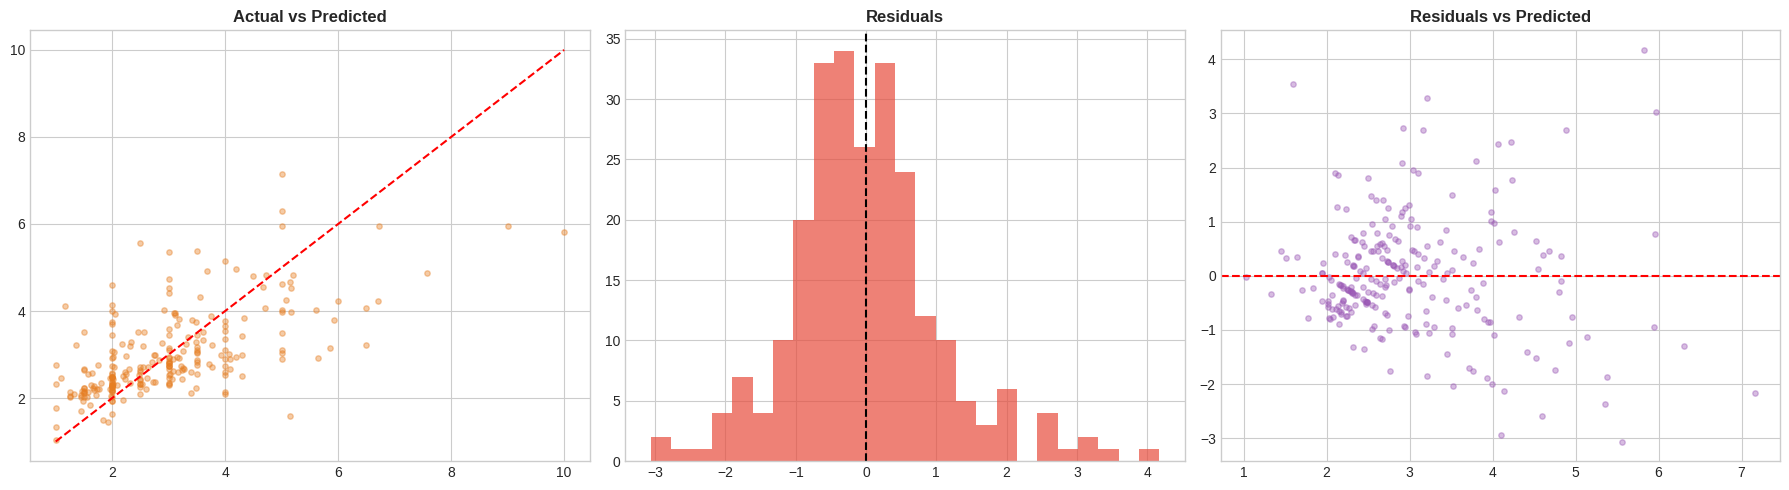

In [8]:
bp=results[best]['preds'];res=y-bp
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].scatter(y,bp,alpha=0.4,s=15,color='#e67e22');lm=[min(y.min(),bp.min()),max(y.max(),bp.max())]
axes[0].plot(lm,lm,'r--');axes[0].set_title('Actual vs Predicted',fontweight='bold')
axes[1].hist(res,bins=25,color='#e74c3c',alpha=0.7);axes[1].axvline(0,color='k',ls='--');axes[1].set_title('Residuals',fontweight='bold')
axes[2].scatter(bp,res,alpha=0.4,s=15,color='#9b59b6');axes[2].axhline(0,color='r',ls='--');axes[2].set_title('Residuals vs Predicted',fontweight='bold')
plt.tight_layout();plt.savefig('resid.png',dpi=150);plt.show()

## 8. Feature Importance

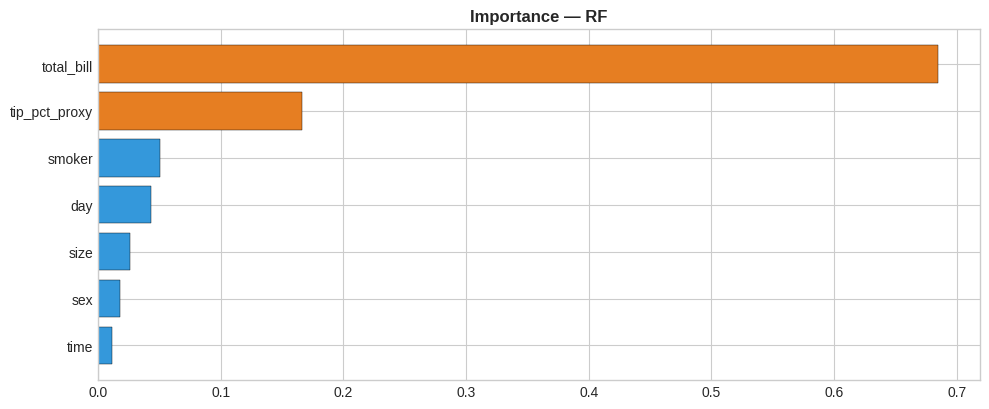

  total_bill           0.6847
  tip_pct_proxy        0.1666
  smoker               0.0503
  day                  0.0432
  size                 0.0257


In [9]:
tm={k:v for k,v in models.items() if k!='Ridge'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['r2']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(4,len(fi)*0.6)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#e67e22' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    for _,r2 in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r2['Feature']:20s} {r2['Imp']:.4f}")

## 9. Deployment

In [10]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  R2:    {br['r2']:.4f}");print(f"  MAE:   ${br['mae']:.2f}")
print(f"  Time:  {br['time']:.1f}s");print(f"  Feats: {X.shape[1]}");print(f"  Rows:  {len(y):,}");print("="*60)
checks={'R2>0.30':br['r2']>0.30,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: Ridge
  R2:    0.3623
  MAE:   $0.79
  Time:  0.0s
  Feats: 7
  Rows:  244

CHECKLIST
----------------------------------------
  [pass] R2>0.30
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [11]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: POS systems, reservation platforms -> Fabric Lakehouse
2. MODEL: Batch analytics for hospitality benchmarking
3. INTEGRATE: Fair Work wage analytics, ATO tip income reporting
4. GOVERN: Privacy (no individual tracking), aggregate analytics only
5. MONITOR: Seasonal trends, retrain with new POS data quarterly
""")


PRODUCTION ARCHITECTURE
1. DATA: POS systems, reservation platforms -> Fabric Lakehouse
2. MODEL: Batch analytics for hospitality benchmarking
3. INTEGRATE: Fair Work wage analytics, ATO tip income reporting
4. GOVERN: Privacy (no individual tracking), aggregate analytics only
5. MONITOR: Seasonal trends, retrain with new POS data quarterly

